# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


For both set of cases ('Infections from wedding' and 'Traced to wedding'), the data seems to take on a normal distribution. For both set of the cases, the 50th quantile and the median for 'Infected cases from the wedding' and 'Traced to the wedding' is 0.2. The mean is very close to the 50th percentile with 'Infections from wedding' having a mean of approx 0.2 and 'Traced to wedding' having a mean of approximately 0.19. This was checked when the original number of repetitions was 1000.

It was difficult to distinguish between the target population, frame population and sample frame population because all felt like they are the same in this scenario. In this case it seems we have access to the entire population which we sampled from, probably because this was a simulation exercise. The following code resulted in the initial creation of 1000 records (simulated people).

Stage 0: Setup ie pd.Dataframe
  ```
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })
  ```


Sampling was done at various stages (multi-staging):


+ Stage 1: Infecting random subset: Simple Random Sampling for randomly choosing which persons get infected. The sample size is the number of people (1000) times the ATTACK_RATE (0.10) which is equal to 100. Since everyone has an equally likely chance of getting infected (10% according to the article), this will be considered as a uniform distribution.

```
infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
ppl.loc[infected_indices, 'infected'] = True
  
```

+ Stage 2 Primary Contact: Simple random sample for selecting which infected case is traced. The sample size will vary. Since this is simulated based on contact tracing, in the real world, probably snowball sampling could have been used for identifying other individuals who were infected, especially for cases connected to brunch. For the wedding, as mentioned in the article, it was possible there could have been a guest list. Since everyone who was infected has an equally likely chance of being traced (20%), this could be considered as a uniform distribution.
 
```
ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS
```

Stage 3: Secondary Contact: In the primary contact stage everyone who was infected has an equally likely chance of being traced. According to the article:
> If two infections are independently traced to the same source event, a special effort is made to test every person who attended that event, with the result that 100% of infections associated with that event are identified. (I have no idea if public health agencies actually do this, but it seems likely.)

This could be more of a poisson distribution since we are approximating that if two infections are independently traced to the same event, then everyone who went to the event and was infected would have been traced since special effort is made to test every person from an event whenever there is 2 or more independent cases traced to that event.

```
event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True
```

Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

I added `np.random.seed(20)` for reproducibility across re-runs.  In terms of changes, I noticed the most visual change from the 1000 repetition when I changed the number of repetitions to 10. However, the 50th quantile (0.195) was still close to the 50th quantile for the 1000 repetition. Visually, the 100 repetitions was more similar to the 1000 repetitions. Also, the 50th quartile for the 100 repetitions was also 0.2, and the mean for both set of cases were closer to the mean for the 1000 reptition experiment. I guess this could be because of the law of large numbers.

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The script needs to produce the same output when run multiple times.

I added `np.random.seed(20)` for reproducibility across re-runs. This kept the output of the result the same across multiple runs for the same number of repetitions. I could close the application and still get the same results. 

## Code

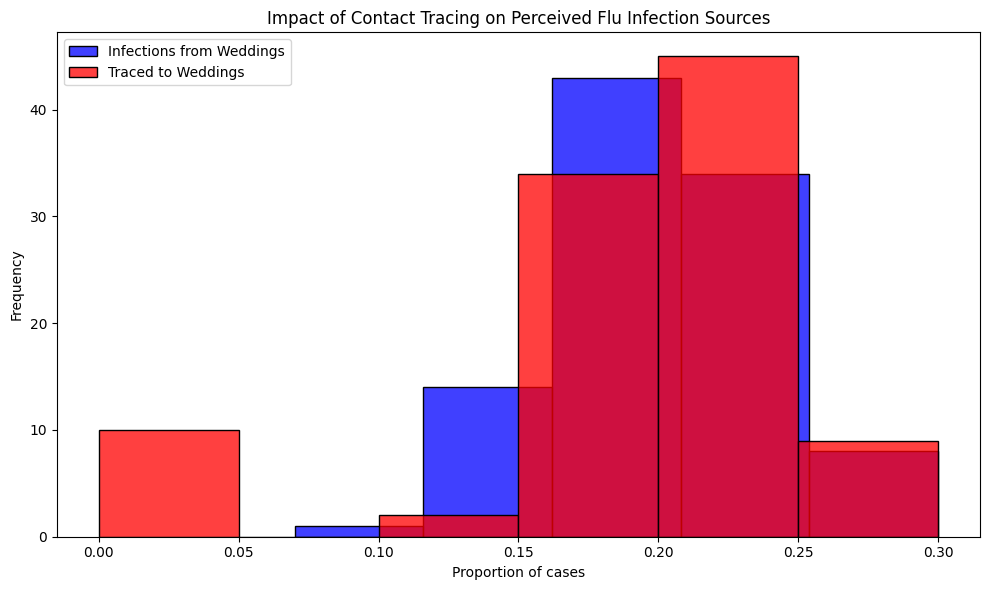

In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2
# For reproducibility
np.random.seed(20)

def simulate_event(m):
  """
  Simulates the infection and tracing process for a series of events.
  
  This function creates a DataFrame representing individuals attending weddings and brunches,
  infects a subset of them based on the ATTACK_RATE, performs primary and secondary contact tracing,
  and calculates the proportions of infections and traced cases that are attributed to weddings.
  
  Parameters:
  - m: Dummy parameter for iteration purposes.
  
  Returns:
  - A tuple containing the proportion of infections and the proportion of traced cases
    that are attributed to weddings.
  """
  # Create DataFrame for people at events with initial infection and traced status
  events = ['wedding'] * 200 + ['brunch'] * 800
  
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Infect a random subset of people
  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  # Secondary contact tracing based on event attendance
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  #print(events_traced)
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True


  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  #print(p_wedding_infections,p_wedding_traces)

  return p_wedding_infections, p_wedding_traces


# Run the simulation 1000 times
results = [simulate_event(m) for m in range(100)]
props_df = pd.DataFrame(results, columns=["Infections", "Traces"])
#print(props_df)

# Plotting the results
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Calculating the quantiles and average for the explanation questions
infection_quantiles = props_df['Infections'].quantile([0.05, 0.5, 0.95])
traced_quantiles =  props_df['Traces'].quantile([0.05, 0.5, 0.95])
print(f"Infections from wedding 50th quantile {infection_quantiles[0.5]}")
print(f"Traced to Weddings 50th quantile {traced_quantiles[0.5]}")

infection_mean = props_df['Infections'].mean()
trace_mean = props_df['Traces'].mean()
print(f"Infections from wedding mean: {infection_mean}")
print(f"Traced to Weddings mean: {trace_mean}")

infection_median = props_df['Infections'].median()
trace_median = props_df['Traces'].median()
print(f"Infections from wedding median: {infection_median}")
print(f"Traced to Weddings median: {trace_median}")

print(infection_quantiles)
print(traced_quantiles)


Infections from wedding 50th quantile 0.2
Traced to Weddings 50th quantile 0.2
Infections from wedding mean: 0.19939999999999997
Traced to Weddings mean: 0.1826670761988484
Infections from wedding median: 0.2
Traced to Weddings median: 0.2
0.05    0.15
0.50    0.20
0.95    0.26
Name: Infections, dtype: float64
0.05    0.012041
0.50    0.200000
0.95    0.260000
Name: Traces, dtype: float64


## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 02 February 2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [ ] Create a branch called `assignment-1`.
- [ ] Ensure that the repository is public.
- [ ] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
